Passenger records: 1265
Crew records: 693
Class records: 3
Department records: 4

DECISION TREE RESULTS
Accuracy: 0.532258064516129

Classification Report:

              precision    recall  f1-score   support

        Band       0.00      0.00      0.00         2
        Deck       0.00      0.00      0.00         7
 Engineering       0.47      0.88      0.61        25
 Victualling       0.85      0.39      0.54        28

    accuracy                           0.53        62
   macro avg       0.33      0.32      0.29        62
weighted avg       0.57      0.53      0.49        62


Decision Tree Rules:

|--- sex_encoded <= 0.50
|   |--- class: 3
|--- sex_encoded >  0.50
|   |--- age <= 21.50
|   |   |--- age <= 16.50
|   |   |   |--- age <= 15.50
|   |   |   |   |--- class: 3
|   |   |   |--- age >  15.50
|   |   |   |   |--- class: 3
|   |   |--- age >  16.50
|   |   |   |--- age <= 18.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  18.50
|   |   |   |   |--- class: 3
|  

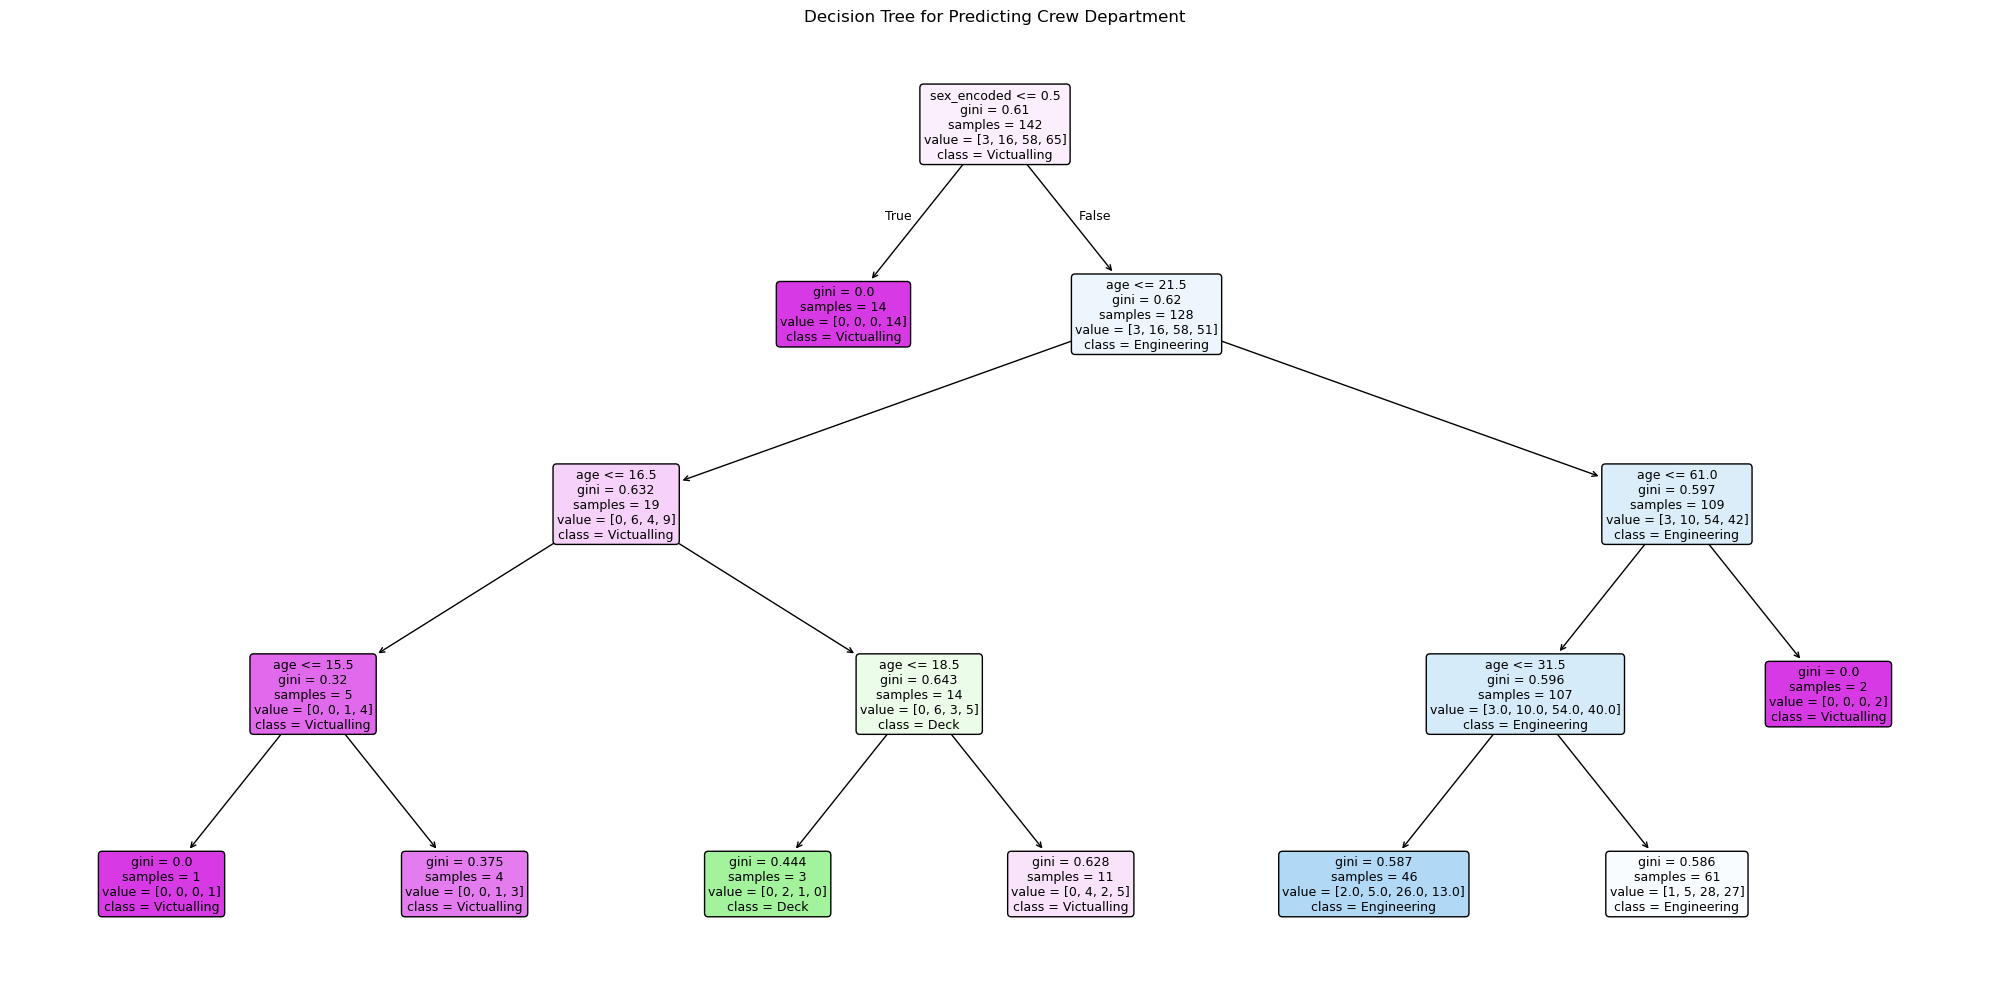


Predicted department for sample case: Engineering

DECISION TREE RESULTS
Accuracy: 0.5592705167173252

Classification Report:

              precision    recall  f1-score   support

      Saloon       0.57      0.67      0.61        84
      Second       0.52      0.79      0.63       137
       Third       0.83      0.19      0.30       108

    accuracy                           0.56       329
   macro avg       0.64      0.55      0.51       329
weighted avg       0.64      0.56      0.52       329


Decision Tree Rules:

|--- citizenship_encoded <= 11.50
|   |--- citizenship_encoded <= 4.50
|   |   |--- age <= 37.50
|   |   |   |--- age <= 8.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  8.50
|   |   |   |   |--- class: 1
|   |   |--- age >  37.50
|   |   |   |--- sex_encoded <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- sex_encoded >  0.50
|   |   |   |   |--- class: 0
|   |--- citizenship_encoded >  4.50
|   |   |--- citizenship_encoded <= 9.50
|   |   |   |--

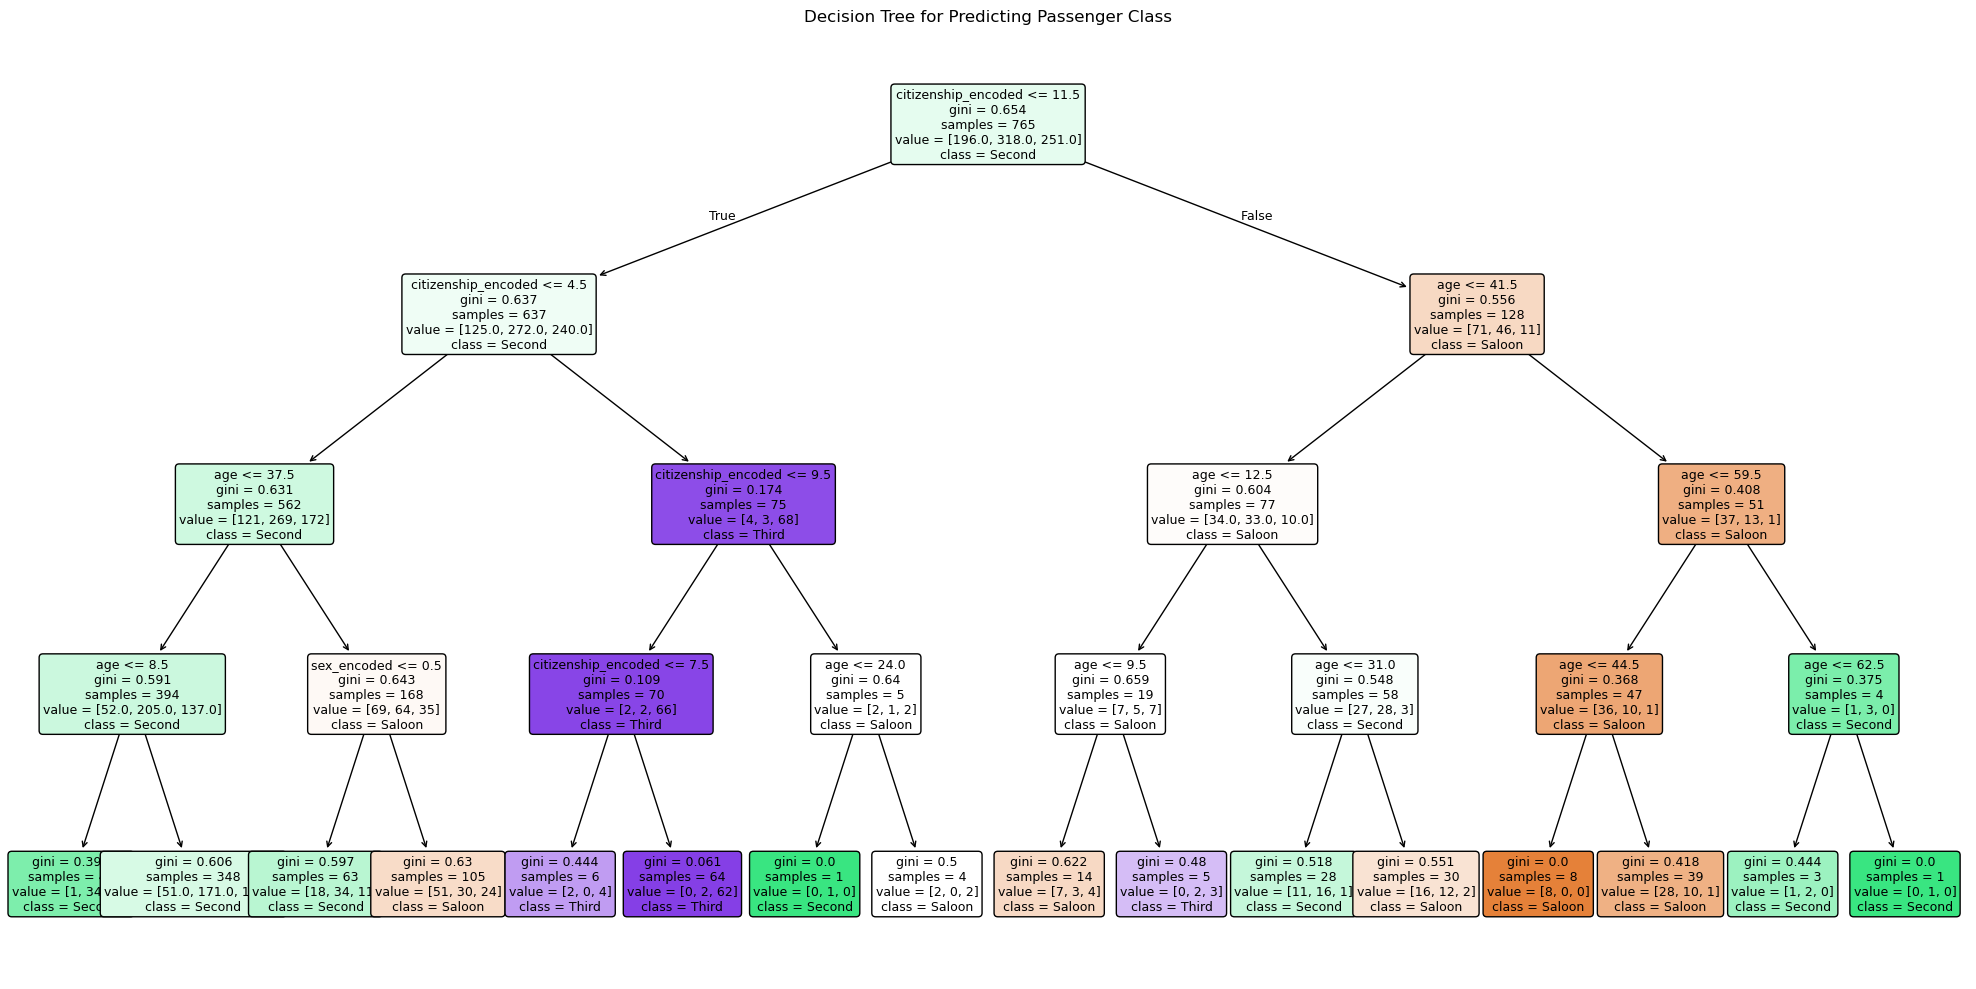


Predicted class for sample case: Second


In [9]:
import sklearn
import matplotlib.pyplot as plt
import sqlite3
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------
# Database connection helper
# ---------------------------
def connect_db(db_name="lusitania.db"):
    conn = sqlite3.connect(db_name)
    conn.execute("PRAGMA foreign_keys = ON;")
    return conn
    
# ---------------------------
# Class Table
# ---------------------------
class TravelClass:
    @staticmethod
    def create_table(conn):
        conn.execute("""
        CREATE TABLE IF NOT EXISTS class_table (
            class_id INTEGER PRIMARY KEY AUTOINCREMENT,
            class_name TEXT NOT NULL UNIQUE
        );
        """)
        conn.commit()

    @staticmethod
    def add_class(conn, class_name):
        conn.execute("""
        INSERT OR IGNORE INTO class_table (class_name)
        VALUES (?);
        """, (class_name,))
        conn.commit()

    @staticmethod
    def get_all_classes(conn):
        cursor = conn.execute("SELECT * FROM class_table ORDER BY class_id;")
        return cursor.fetchall()

    @staticmethod
    def get_class_id_by_name(conn, class_name):
        cursor = conn.execute("""
        SELECT class_id
        FROM class_table
        WHERE class_name = ?;
        """, (class_name,))
        row = cursor.fetchone()
        return row[0] if row else None

# ---------------------------
# Passenger Table
# ---------------------------
class Passenger:
    @staticmethod
    def create_table(conn):
        conn.execute("""
        CREATE TABLE IF NOT EXISTS passenger (
            passenger_id INTEGER PRIMARY KEY,
            family_name TEXT,
            title TEXT,
            personal_name TEXT,
            age TEXT,
            citizenship TEXT,
            city TEXT,
            adult_minor TEXT,
            sex TEXT,
            status TEXT,
            class_id INTEGER,
            FOREIGN KEY (class_id) REFERENCES class_table(class_id)
                ON DELETE SET NULL
                ON UPDATE CASCADE
        );
        """)
        conn.commit()

    @staticmethod
    def add_passenger(conn, passenger_id, family_name, title, personal_name,
                      age, citizenship, city, adult_minor, sex, status, class_id):
        conn.execute("""
        INSERT OR REPLACE INTO passenger
        (passenger_id, family_name, title, personal_name, age, citizenship,
         city, adult_minor, sex, status, class_id)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?);
        """, (
            passenger_id, family_name, title, personal_name, age,
            citizenship, city, adult_minor, sex, status, class_id
        ))
        conn.commit()

    @staticmethod
    def get_all_passengers(conn):
        cursor = conn.execute("""
        SELECT *
        FROM passenger
        ORDER BY passenger_id;
        """)
        return cursor.fetchall()

    @staticmethod
    def get_passengers_older_than_30(conn):
        cursor = conn.execute("""
        SELECT * FROM passenger WHERE age > 30 """)
        return cursor.fetchall()

    @staticmethod
    def list_passengers_with_class(conn):
        cursor = conn.execute("""
        SELECT
            p.passenger_id,
            p.personal_name,
            p.family_name,
            c.class_name
        FROM passenger p
        LEFT JOIN class_table c
            ON p.class_id = c.class_id
        ORDER BY p.passenger_id;
        """)
        return cursor.fetchall()

    @staticmethod
    def train_class_decision_tree(conn, max_depth=4, test_size=0.3):
        query = """
        SELECT
            p.age,
            p.sex,
            p.citizenship,
            p.adult_minor,
            c.class_name
        FROM passenger p
        JOIN class_table c
            ON p.class_id = c.class_id
        WHERE p.age IS NOT NULL
          AND p.sex IS NOT NULL
          AND p.citizenship IS NOT NULL
          AND p.adult_minor IS NOT NULL
          AND c.class_name IS NOT NULL;
        """

        df = pd.read_sql_query(query, conn)

        if df.empty:
            print("No passenger data found for training.")
            return None

        # Clean age column
        df["age"] = pd.to_numeric(df["age"], errors="coerce")
        df = df.dropna(subset=["age"])

        if df.empty:
            print("No valid numeric age values found after cleaning.")
            return None

        # Encode categorical fields
        sex_encoder = LabelEncoder()
        citizenship_encoder = LabelEncoder()
        adult_minor_encoder = LabelEncoder()
        target_encoder = LabelEncoder()

        df["sex_encoded"] = sex_encoder.fit_transform(df["sex"].astype(str))
        df["citizenship_encoded"] = citizenship_encoder.fit_transform(df["citizenship"].astype(str))
        df["adult_minor_encoded"] = adult_minor_encoder.fit_transform(df["adult_minor"].astype(str))
        df["target"] = target_encoder.fit_transform(df["class_name"].astype(str))

        # Features and target
        X = df[["age", "sex_encoded", "citizenship_encoded", "adult_minor_encoded"]]
        y = df["target"]

        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=42,
            stratify=y
        )

        # Train model
        model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Report
        print("\n==============================")
        print("DECISION TREE RESULTS")
        print("==============================")
        print("Accuracy:", accuracy_score(y_test, y_pred))

        print("\nClassification Report:\n")
        print(classification_report(
            y_test,
            y_pred,
            target_names=target_encoder.classes_,
            zero_division=0
        ))

        print("\nDecision Tree Rules:\n")
        print(export_text(
            model,
            feature_names=["age", "sex_encoded", "citizenship_encoded", "adult_minor_encoded"]
        ))

        print("\nEncoding Keys:")
        print("sex:", dict(zip(sex_encoder.classes_, sex_encoder.transform(sex_encoder.classes_))))
        print("citizenship:", dict(zip(citizenship_encoder.classes_, citizenship_encoder.transform(citizenship_encoder.classes_))))
        print("adult_minor:", dict(zip(adult_minor_encoder.classes_, adult_minor_encoder.transform(adult_minor_encoder.classes_))))
        print("department_name:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

        # Plot tree
        plt.figure(figsize=(20, 10))
        plot_tree(
            model,
            feature_names=["age", "sex_encoded", "citizenship_encoded", "adult_minor_encoded"],
            class_names=target_encoder.classes_,
            filled=True,
            rounded=True,
            fontsize=9
        )
        plt.title("Decision Tree for Predicting Passenger Class")
        plt.tight_layout()
        plt.show()

        return {
            "model": model,
            "target_encoder": target_encoder,
            "sex_encoder": sex_encoder,
            "citizenship_encoder": citizenship_encoder,
            "adult_minor_encoder": adult_minor_encoder,
            "training_dataframe": df
        }

    @staticmethod
    def predict_class(model_bundle_passenger, age, sex, citizenship, adult_minor):
        if model_bundle_passenger is None:
            print("No trained model available.")
            return None

        model = model_bundle_passenger["model"]
        target_encoder = model_bundle_passenger["target_encoder"]
        sex_encoder = model_bundle_passenger["sex_encoder"]
        citizenship_encoder = model_bundle_passenger["citizenship_encoder"]
        adult_minor_encoder = model_bundle_passenger["adult_minor_encoder"]

        sample = pd.DataFrame([{
            "age": age,
            "sex_encoded": sex_encoder.transform([sex])[0],
            "citizenship_encoded": citizenship_encoder.transform([citizenship])[0],
            "adult_minor_encoded": adult_minor_encoder.transform([adult_minor])[0]
        }])

        prediction = model.predict(sample)[0]
        return target_encoder.inverse_transform([prediction])[0]

# ---------------------------
# Department Table
# ---------------------------
class Department:
    @staticmethod
    def create_table(conn):
        conn.execute("""
        CREATE TABLE IF NOT EXISTS department (
            department_id INTEGER PRIMARY KEY AUTOINCREMENT,
            department_name TEXT NOT NULL UNIQUE
        );
        """)
        conn.commit()

    @staticmethod
    def add_department(conn, department_name):
        conn.execute("""
        INSERT OR IGNORE INTO department (department_name)
        VALUES (?);
        """, (department_name,))
        conn.commit()

    @staticmethod
    def get_all_departments(conn):
        cursor = conn.execute("SELECT * FROM department ORDER BY department_id;")
        return cursor.fetchall()

    @staticmethod
    def get_department_id_by_name(conn, department_name):
        cursor = conn.execute("""
        SELECT department_id
        FROM department
        WHERE department_name = ?;
        """, (department_name,))
        row = cursor.fetchone()
        return row[0] if row else None

# ---------------------------
# Crew Table
# ---------------------------
class Crew:
    @staticmethod
    def create_table(conn):
        conn.execute("""
        CREATE TABLE IF NOT EXISTS crew (
            crew_id INTEGER PRIMARY KEY,
            family_name TEXT,
            title TEXT,
            personal_name TEXT,
            age TEXT,
            citizenship TEXT,
            city TEXT,
            adult_minor TEXT,
            sex TEXT,
            position TEXT,
            department_id INTEGER,
            FOREIGN KEY (department_id) REFERENCES department(department_id)
                ON DELETE SET NULL
                ON UPDATE CASCADE
        );
        """)
        conn.commit()

    @staticmethod
    def add_crew(conn, crew_id, family_name, title, personal_name,
                 age, citizenship, city, adult_minor, sex, position, department_id):
        conn.execute("""
        INSERT OR REPLACE INTO crew
        (crew_id, family_name, title, personal_name, age, citizenship,
         city, adult_minor, sex, position, department_id)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            crew_id, family_name, title, personal_name, age,
            citizenship, city, adult_minor, sex, position, department_id
        ))
        conn.commit()

    @staticmethod
    def get_all_crew(conn):
        cursor = conn.execute("""
        SELECT *
        FROM crew
        ORDER BY crew_id;
        """)
        return cursor.fetchall()

    @staticmethod
    def list_crew_with_department(conn):
        cursor = conn.execute("""
        SELECT
            c.crew_id,
            c.personal_name,
            c.family_name,
            c.position,
            d.department_name
        FROM crew c
        LEFT JOIN department d
            ON c.department_id = d.department_id
        ORDER BY c.crew_id;
        """)
        return cursor.fetchall()

    @staticmethod
    def train_department_decision_tree(conn, max_depth=4, test_size=0.3):
        """
        Train a decision tree using crew data to predict department_name.
        Features used:
            - age
            - sex
            - citizenship
            - adult_minor

        Returns a dictionary containing the model and encoders.
        """

        query = """
        SELECT
            c.age,
            c.sex,
            c.citizenship,
            c.adult_minor,
            d.department_name
        FROM crew c
        JOIN department d
            ON c.department_id = d.department_id
        WHERE c.age IS NOT NULL
          AND c.sex IS NOT NULL
          AND c.citizenship IS NOT NULL
          AND c.adult_minor IS NOT NULL
          AND d.department_name IS NOT NULL;
        """

        df = pd.read_sql_query(query, conn)

        if df.empty:
            print("No crew data found for training.")
            return None

        # Clean age column
        df["age"] = pd.to_numeric(df["age"], errors="coerce")
        df = df.dropna(subset=["age"])

        if df.empty:
            print("No valid numeric age values found after cleaning.")
            return None

        # Encode categorical fields
        sex_encoder = LabelEncoder()
        citizenship_encoder = LabelEncoder()
        adult_minor_encoder = LabelEncoder()
        target_encoder = LabelEncoder()

        df["sex_encoded"] = sex_encoder.fit_transform(df["sex"].astype(str))
        df["citizenship_encoded"] = citizenship_encoder.fit_transform(df["citizenship"].astype(str))
        df["adult_minor_encoded"] = adult_minor_encoder.fit_transform(df["adult_minor"].astype(str))
        df["target"] = target_encoder.fit_transform(df["department_name"].astype(str))

        # Features and target
        X = df[["age", "sex_encoded", "citizenship_encoded", "adult_minor_encoded"]]
        y = df["target"]

        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=42,
            stratify=y
        )

        # Train model
        model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Report
        print("\n==============================")
        print("DECISION TREE RESULTS")
        print("==============================")
        print("Accuracy:", accuracy_score(y_test, y_pred))

        print("\nClassification Report:\n")
        print(classification_report(
            y_test,
            y_pred,
            target_names=target_encoder.classes_,
            zero_division=0
        ))

        print("\nDecision Tree Rules:\n")
        print(export_text(
            model,
            feature_names=["age", "sex_encoded", "citizenship_encoded", "adult_minor_encoded"]
        ))

        print("\nEncoding Keys:")
        print("sex:", dict(zip(sex_encoder.classes_, sex_encoder.transform(sex_encoder.classes_))))
        print("citizenship:", dict(zip(citizenship_encoder.classes_, citizenship_encoder.transform(citizenship_encoder.classes_))))
        print("adult_minor:", dict(zip(adult_minor_encoder.classes_, adult_minor_encoder.transform(adult_minor_encoder.classes_))))
        print("department_name:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

        # Plot tree
        plt.figure(figsize=(20, 10))
        plot_tree(
            model,
            feature_names=["age", "sex_encoded", "citizenship_encoded", "adult_minor_encoded"],
            class_names=target_encoder.classes_,
            filled=True,
            rounded=True,
            fontsize=9
        )
        plt.title("Decision Tree for Predicting Crew Department")
        plt.tight_layout()
        plt.show()

        return {
            "model": model,
            "target_encoder": target_encoder,
            "sex_encoder": sex_encoder,
            "citizenship_encoder": citizenship_encoder,
            "adult_minor_encoder": adult_minor_encoder,
            "training_dataframe": df
        }

    @staticmethod
    def predict_department(model_bundle, age, sex, citizenship, adult_minor):
        """
        Predict a department using the trained model bundle.
        """
        if model_bundle is None:
            print("No trained model available.")
            return None

        model = model_bundle["model"]
        target_encoder = model_bundle["target_encoder"]
        sex_encoder = model_bundle["sex_encoder"]
        citizenship_encoder = model_bundle["citizenship_encoder"]
        adult_minor_encoder = model_bundle["adult_minor_encoder"]

        sample = pd.DataFrame([{
            "age": age,
            "sex_encoded": sex_encoder.transform([sex])[0],
            "citizenship_encoded": citizenship_encoder.transform([citizenship])[0],
            "adult_minor_encoded": adult_minor_encoder.transform([adult_minor])[0]
        }])

        prediction = model.predict(sample)[0]
        return target_encoder.inverse_transform([prediction])[0]

# ---------------------------
# Create all tables
# ---------------------------
def create_all_tables(conn):
    TravelClass.create_table(conn)
    Passenger.create_table(conn)
    Department.create_table(conn)
    Crew.create_table(conn)

# ---------------------------
# Load CSV into database
# ---------------------------
def load_lusitania_data(conn, csv_file):
    df = pd.read_csv(csv_file)

    # Clean column names just in case
    df.columns = [col.strip() for col in df.columns]

    # Separate passengers and crew
    passenger_df = df[df["Passenger/Crew"] == "Passenger"].copy()
    crew_df = df[df["Passenger/Crew"] == "Crew"].copy()

    # ---------------------------
    # Load passenger classes
    # ---------------------------
    passenger_classes = (
        passenger_df["Department/Class"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
    )

    for class_name in sorted(passenger_classes):
        TravelClass.add_class(conn, class_name)

    # ---------------------------
    # Load crew departments
    # ---------------------------
    crew_departments = (
        crew_df["Department/Class"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
    )

    for dept_name in sorted(crew_departments):
        Department.add_department(conn, dept_name)

    # ---------------------------
    # Load passengers
    # ---------------------------
    for _, row in passenger_df.iterrows():
        class_name = str(row["Department/Class"]).strip() if pd.notna(row["Department/Class"]) else None
        class_id = TravelClass.get_class_id_by_name(conn, class_name) if class_name else None

        Passenger.add_passenger(
            conn=conn,
            passenger_id=int(row["ID"]),
            family_name=row["Family_name"],
            title=row["Title"],
            personal_name=row["Personal_name"],
            age=str(row["Age"]) if pd.notna(row["Age"]) else None,
            citizenship=row["Citizenship"],
            city=row["City"],
            adult_minor=row["Adult/Minor"],
            sex=row["Sex"],
            status=row["Status"],
            class_id=class_id
        )

    # ---------------------------
    # Load crew
    # ---------------------------
    for _, row in crew_df.iterrows():
        dept_name = str(row["Department/Class"]).strip() if pd.notna(row["Department/Class"]) else None
        department_id = Department.get_department_id_by_name(conn, dept_name) if dept_name else None

        Crew.add_crew(
            conn=conn,
            crew_id=int(row["ID"]),
            family_name=row["Family_name"],
            title=row["Title"],
            personal_name=row["Personal_name"],
            age=str(row["Age"]) if pd.notna(row["Age"]) else None,
            citizenship=row["Citizenship"],
            city=row["City"],
            adult_minor=row["Adult/Minor"],
            sex=row["Sex"],
            position=row["Position"],
            department_id=department_id
        )

# ---------------------------
# Example queries
# ---------------------------
def show_counts(conn):
    passenger_count = conn.execute("SELECT COUNT(*) FROM passenger;").fetchone()[0]
    crew_count = conn.execute("SELECT COUNT(*) FROM crew;").fetchone()[0]
    class_count = conn.execute("SELECT COUNT(*) FROM class_table;").fetchone()[0]
    department_count = conn.execute("SELECT COUNT(*) FROM department;").fetchone()[0]

    print("Passenger records:", passenger_count)
    print("Crew records:", crew_count)
    print("Class records:", class_count)
    print("Department records:", department_count)

def show_sample_data(conn):
    print("\nCLASSES")
    print(TravelClass.get_all_classes(conn))

    print("\nDEPARTMENTS")
    print(Department.get_all_departments(conn))

    print("\nFIRST 10 PASSENGERS WITH CLASS")
    rows = Passenger.list_passengers_with_class(conn)[:10]
    for row in rows:
        print(row)

    print("\nFIRST 10 CREW WITH DEPARTMENT")
    rows = Crew.list_crew_with_department(conn)[:10]
    for row in rows:
        print(row)

    print("\nPASSENGERS OLDER THAN 30")
    rows = Passenger.get_passengers_older_than_30(conn)
    for row in rows:
        print(row)

# ---------------------------
# Main
# ---------------------------
if __name__ == "__main__":
    csv_file = "LusitaniaManifest.csv"   # put the CSV in the same folder as this script
    conn = connect_db("lusitania_2.db")

    create_all_tables(conn)
    load_lusitania_data(conn, csv_file)

    show_counts(conn)
    #show_sample_data(conn)

    model_bundle = Crew.train_department_decision_tree(conn, max_depth=4, test_size=0.3)

    # predicting which department a crew member would most likely belong based on their sex, age, nationality,
    # and whether they were Adult or a Child
    
    if model_bundle:
        try:
            predicted_department = Crew.predict_department(
                model_bundle,
                age=35,
                sex="Male",
                citizenship="British",
                adult_minor="Adult"
            )
            print("\nPredicted department for sample case:", predicted_department)
        except ValueError as e:
            print("\nPrediction Error:", e)

    # decision tree that predicts the class a passenger would be added to based on their sex, 
    # citizenship and their status as adult/minor.

    model_bundle_passenger = Passenger.train_class_decision_tree(conn, max_depth=4, test_size=0.3)
    
    if model_bundle_passenger:
        try:
            predicted_class = Passenger.predict_class(
                model_bundle_passenger,
                age=30,
                sex="Female",
                citizenship="British",
                adult_minor="Adult"
            )
            print("\nPredicted class for sample case:", predicted_class)
        except ValueError as e:
            print("\nPrediction Error:", e)

    conn.close()

ERROR: unknown command "update"
